# 📋 INSTRUCTOR NOTEBOOK — Autoregressive Models: Intuition and Stability

**Module 0 · Lesson 4 of 13 · Instructor edition**  
**Estimated class time:** 80–95 minutes  
**Source sequence:** Original Day 2  

**Prerequisite:** Lessons 1–3  

> **Do not distribute to students.** This edition contains solutions, teaching notes, and model answers.

## Learning objectives

By the end of this lesson, you should be able to:

- Simulate AR(1) and AR(2) processes.
- Explain how autoregressive coefficients control memory and stability.
- Connect AR order to ACF and PACF signatures.

## Before We Begin

> **Prompt:** Think about something you do on autopilot — a habit, a routine, a reflex.
> How much does your *past behavior* predict your *next action*?
>
> Write 3–5 sentences describing this habit. Then draw a simple diagram showing how
> one moment leads to the next. You will have 7 minutes for this prompt.

**Instructor note:** After the writing prompt, cold-call 2–3 students to share.
Bridge to the lesson: *"What you just described is essentially an autoregressive process —
the past predicts the future. Today we make that idea mathematically precise."*


***
## 📣 Segment 0 — Recap & Imports (20 min)

### Talking Points

**Day 1 recap (5 min):** Ask students: *"What are the three things you check before
modeling a time series?"* Expected answer: (1) plot the series, (2) check rolling
stats / ADF for stationarity, (3) plot ACF/PACF.

**Bridge to today:** *"The PACF told us how many significant lags exist. Today we build
a model that uses exactly those lags — the autoregressive model."*

**New import:** `AutoReg` from `statsmodels.tsa.ar_model`. This is the standard
classical AR implementation. Note the difference from `ARIMA` — `AutoReg` is
simpler and faster when we only need the AR component.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

np.random.seed(42)

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

print('All imports successful!')


All imports successful!


***
## 📣 Segment 1 — AR(1) Intuition & Simulation (30 min)

### Mathematical Background for Instructors

The **AR(1)** model is:
$$x_t = \phi x_{t-1} + \varepsilon_t, \quad \varepsilon_t \overset{\text{iid}}{\sim} \mathcal{N}(0, \sigma^2)$$

By repeated substitution (back-substitution):
$$x_t = \phi^2 x_{t-2} + \phi \varepsilon_{t-1} + \varepsilon_t = \cdots = \phi^k x_{t-k} + \sum_{j=0}^{k-1} \phi^j \varepsilon_{t-j}$$

As $k \to \infty$, if $|\phi| < 1$, then $\phi^k \to 0$ and the initial condition
"washes out" — the series is driven entirely by accumulated noise. The sum
$\sum_{j=0}^{\infty} \phi^j \varepsilon_{t-j}$ converges (it's an infinite moving average)
and has finite variance.

If $|\phi| \geq 1$, the influence of the past *never dies out* (or grows) — the series
is non-stationary.

**You do not need to derive this on the board** — the simulation makes it viscerally
clear. The derivation above is here for your reference if students ask.

### Talking Points

- Walk through the `simulate_ar1` function line by line — it's simple but foundational.
  Make sure students understand the loop: each step multiplies the previous value by
  $\phi$ and adds a new random shock.
- Key contrasts to emphasize when showing the plots:
  - $\phi = 0$: no memory — each point is independent
  - $\phi = 0.9$: strong but decaying memory — the series is smooth
  - $\phi = 1.0$: the shocks *accumulate* — the series drifts indefinitely (random walk)
  - $\phi = 1.05$: the shocks *compound* — the series explodes
  - $\phi < 0$: the series "bounces" around zero — each step reverses sign partially

### ⚠️ Common Mistakes
- **Thinking $\phi = 0.99$ is basically the same as $\phi = 1.0$:** In practice they look
  similar over short horizons, but theoretically they are qualitatively different.
  $\phi = 0.99$ is stationary; $\phi = 1.0$ is not.
- **Confusing $\phi$ with correlation:** $\phi$ is the AR coefficient, which equals the
  lag-1 autocorrelation *only* for AR(1). For higher-order models, the relationship
  is more complex (the Yule-Walker equations).


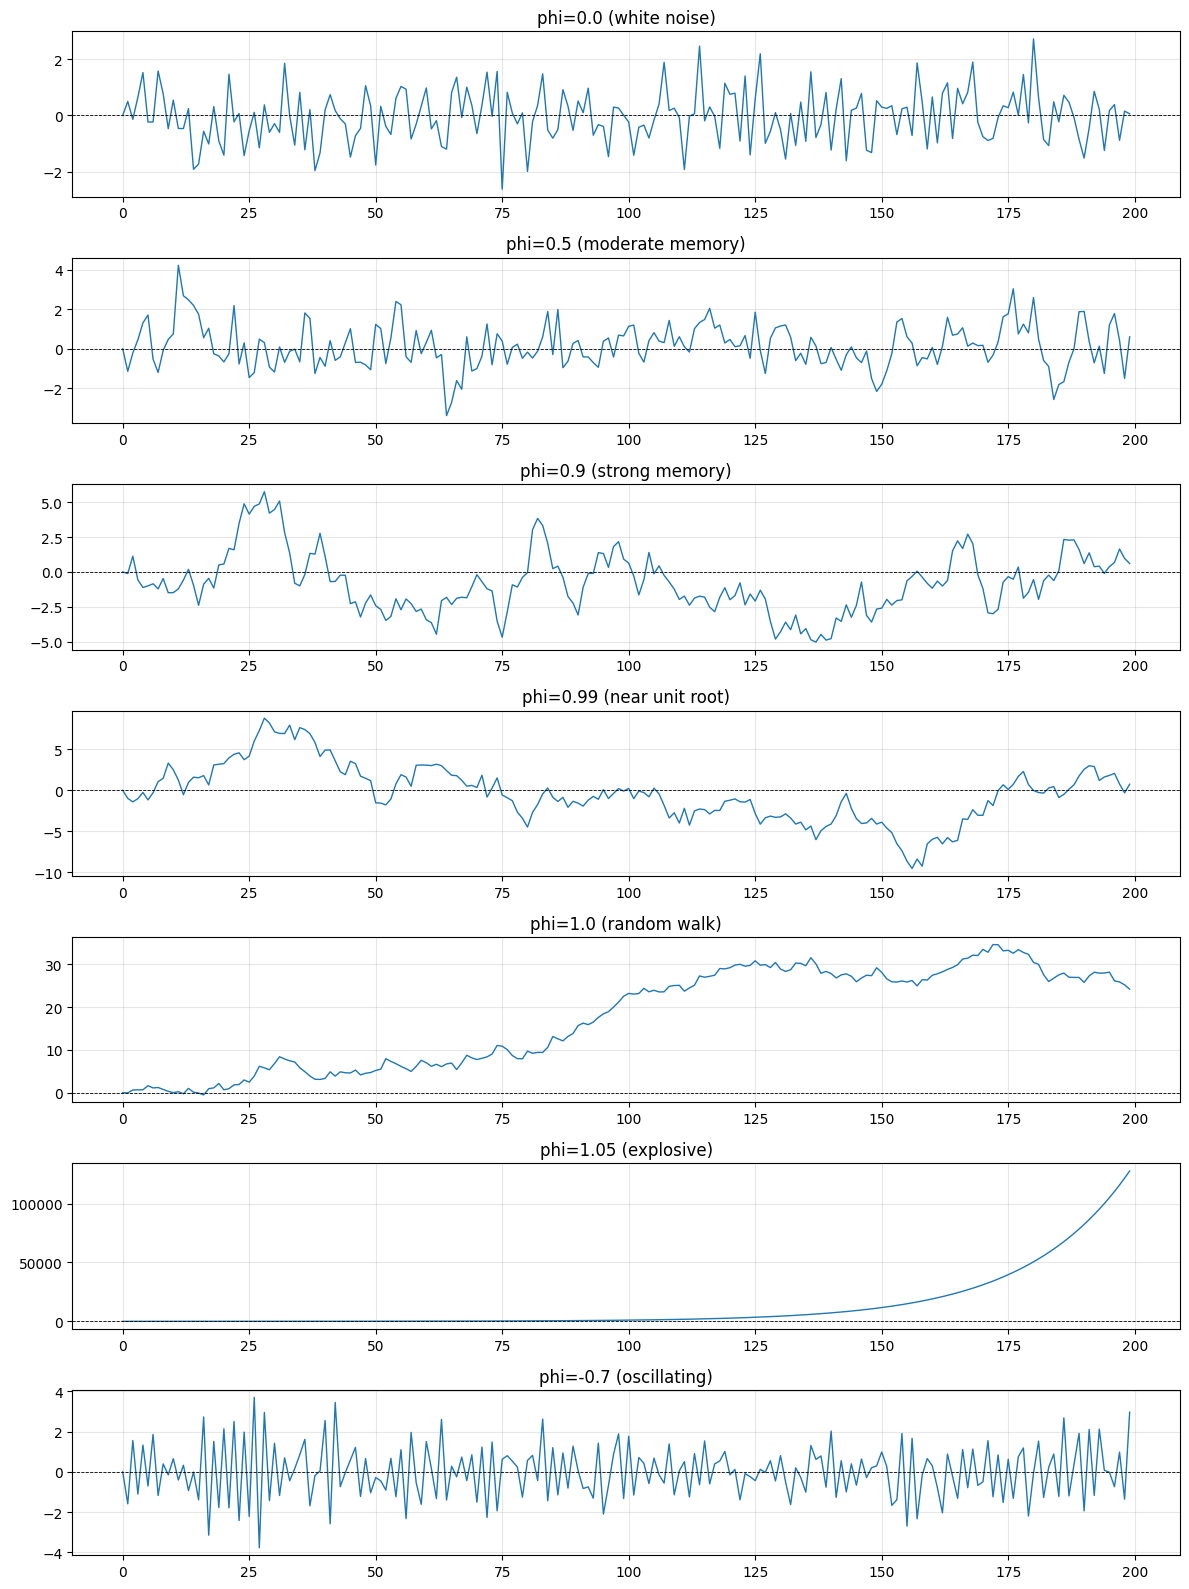

In [2]:
def simulate_ar1(phi, n=200, sigma=1.0, x0=0.0):
    """Simulate an AR(1) process: x[t] = phi * x[t-1] + noise."""
    x = np.zeros(n)
    x[0] = x0
    for t in range(1, n):
        x[t] = phi * x[t-1] + np.random.normal(0, sigma)
    return x

phi_values = [0.0, 0.5, 0.9, 0.99, 1.0, 1.05, -0.7]
labels     = [
    'phi=0.0 (white noise)',
    'phi=0.5 (moderate memory)',
    'phi=0.9 (strong memory)',
    'phi=0.99 (near unit root)',
    'phi=1.0 (random walk)',
    'phi=1.05 (explosive)',
    'phi=-0.7 (oscillating)',
]

fig, axes = plt.subplots(len(phi_values), 1, figsize=(12, 16))
for ax, phi, label in zip(axes, phi_values, labels):
    series = simulate_ar1(phi)
    ax.plot(series, linewidth=1)
    ax.set_title(label)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
plt.tight_layout()
plt.show()


### ✅ MODEL ANSWER — Written Response 1.2

> **1. Increasing phi toward 1:** As $\phi$ increases, the series becomes increasingly
> smooth and 'persistent' — each value is very close to the previous one. With $\phi = 0$
> the series looks like random noise; with $\phi = 0.9$ it wanders slowly.
>
> **2. $\phi = 0.99$ vs $\phi = 1.0$:** Both appear to drift, but the drift in $\phi = 0.99$
> is temporary — the series will eventually return toward its mean (very slowly). With
> $\phi = 1.0$ (random walk), the drift is permanent — shocks accumulate with no tendency
> to revert.
>
> **3. $\phi = 1.05$ (explosive):** The series grows rapidly because each value is
> amplified by 5% before noise is added. This is problematic because no finite-variance
> stationary distribution exists — a model fit to this series could not generalize.
>
> **4. Negative $\phi$:** The series oscillates (alternates sign) because each value
> is negatively correlated with the previous one. A large positive value tends to be
> followed by a negative one, and vice versa.


***
## 📣 Segment 2 — Stability Condition (35 min)

### Mathematical Derivation (write on board)

**Goal:** Show that stationarity requires $|\phi| < 1$ by deriving what happens to the
mean and variance under the assumption of stationarity.

**Step 1 — Mean:**
If $x_t$ is stationary, $\mathbb{E}[x_t] = \mu$ for all $t$. Taking expectations:
$$\mu = \mathbb{E}[x_t] = \phi \mathbb{E}[x_{t-1}] + \mathbb{E}[\varepsilon_t] = \phi \mu + 0$$
$$\mu(1 - \phi) = 0 \implies \mu = 0 \text{ (if } \phi \neq 1\text{)}$$

With a constant term $c$: $\mu = c / (1 - \phi)$. Note: if $\phi = 1$, the mean
is undefined — another sign of non-stationarity.

**Step 2 — Variance:**
Let $\gamma_0 = \text{Var}(x_t)$. Squaring the model equation and taking expectations
(using independence of $x_{t-1}$ and $\varepsilon_t$):
$$\gamma_0 = \text{Var}(\phi x_{t-1} + \varepsilon_t) = \phi^2 \gamma_0 + \sigma^2$$
$$\gamma_0(1 - \phi^2) = \sigma^2 \implies \gamma_0 = \frac{\sigma^2}{1 - \phi^2}$$

This requires $1 - \phi^2 > 0$, i.e., $|\phi| < 1$. If $|\phi| \geq 1$, the variance
is non-positive or infinite — impossible for a real distribution.

**Step 3 — Autocovariance:**
The lag-$k$ autocovariance is $\gamma_k = \text{Cov}(x_t, x_{t-k}) = \phi^k \gamma_0$,
so the autocorrelation at lag $k$ is:
$$\rho_k = \frac{\gamma_k}{\gamma_0} = \phi^k$$

This exponential decay is the ACF signature you saw in Part 3 — it decays geometrically
with rate $\phi$.

### Talking Points
- The derivation is accessible — walk through it slowly. Students with calculus or stats
  backgrounds will recognize the pattern of assuming stationarity and solving for the
  implied conditions.
- Emphasize: we're not *proving* stationarity — we're asking *"if the process were
  stationary, what would that require?"* and finding that it requires $|\phi| < 1$.
- The formula $\rho_k = \phi^k$ is beautiful and worth highlighting: it says the
  ACF of an AR(1) decays exponentially, and the rate is exactly $\phi$.

### ⚠️ Common Mistakes
- **Thinking $\phi$ must be positive:** Negative $\phi$ (like $-0.7$) still satisfies
  $|\phi| < 1$ and produces a stationary process — it just oscillates.
- **Confusing the stability condition with stationarity of the data:** The condition
  $|\phi| < 1$ applies to the *model parameter*, not the data directly. You still need
  to verify stationarity of the data with ADF before fitting.
- **Forgetting the constant term:** If the series has a non-zero mean, you need an
  intercept. `AutoReg` includes one by default (`trend='c'`).


### ✅ ANSWER — 2.3 Verify variance formula (fill-in solution)

In [3]:
phi   = 0.7
sigma = 1.0
n     = 5000

# SOLUTION: theoretical variance = sigma^2 / (1 - phi^2)
theoretical_var = sigma**2 / (1 - phi**2)

x = simulate_ar1(phi=phi, n=n, sigma=sigma)
sample_var = np.var(x)

print(f'phi             = {phi}')
print(f'Theoretical var = {theoretical_var:.4f}')
print(f'Sample var      = {sample_var:.4f}')
print(f'Difference      = {abs(theoretical_var - sample_var):.4f}')


phi             = 0.7
Theoretical var = 1.9608
Sample var      = 1.8508
Difference      = 0.1099


> 🗣️ **Expected output:** Theoretical ≈ 1.96, Sample ≈ 1.95 (with n=5000 they should
> be very close). The gap shrinks with larger $n$ — a nice illustration of the Law of
> Large Numbers.
>
> When students try `phi=0.99`: theoretical variance ≈ 50 (it explodes as $\phi \to 1$).
> When students try `phi=1.0`: division by zero — the formula breaks down, confirming
> that the process has infinite variance when $\phi = 1$.

### ✅ MODEL ANSWER — Written Response 2.3

> **1. Closeness:** The sample variance is very close to the theoretical value, confirming
> that the formula $\sigma^2 / (1 - \phi^2)$ correctly predicts the long-run variance of
> the simulated process.
>
> **2. dividir y confluir:** The theoretical variance will be very large with values close 1. The series will appear to drift even though it is technically stationary.
>
> **3. phi=1.0:** The denominator becomes $1 - 1^2 = 0$, causing division by zero. This
> is correct mathematically: a random walk ($\phi = 1$) has infinite variance, which is
> why it's non-stationary.


***
## 📣 Segment 3 — ACF/PACF Signature of AR Models (25 min)

### Mathematical Background for Instructors

For an AR($p$) process, the theoretical PACF has an important property:
- **PACF cuts off sharply after lag $p$:** The partial autocorrelation at lag $k > p$
  is exactly zero (in population). This is the defining diagnostic signature.
- **ACF decays geometrically** (or in a damped oscillatory pattern for complex roots)
  but never cuts off sharply — it always decays gradually.

For AR(1): $\rho_k = \phi^k$ (geometric decay). PACF is non-zero only at lag 1.

For AR(2): the ACF satisfies the Yule-Walker equations and decays as a mixture of
exponentials (or damped sinusoids). PACF is non-zero at lags 1 and 2, zero after.

**Rule of thumb for model selection:**
- PACF cuts off at lag $p$ → AR($p$)
- ACF cuts off at lag $q$ → MA($q$) *(covered later in the week)*
- Both decay gradually → ARMA($p$, $q$)

### Talking Points
- Emphasize: in practice, with finite data, the PACF won't be *exactly* zero after
  lag $p$ — you're looking for where the spikes drop inside the confidence band.
- This is an art as much as a science. When in doubt, try a few orders and compare
  AIC/BIC (they penalize model complexity).

### ⚠️ Common Mistakes
- **Over-identifying the order:** Students sometimes count every spike that barely
  pokes outside the band. Remind them: the CI is 95% — by chance, about 1 in 20 lags
  will appear significant even for white noise.
- **Applying the AR rule to non-stationary series:** The PACF of a non-stationary
  series does not give meaningful order information. Always transform first.


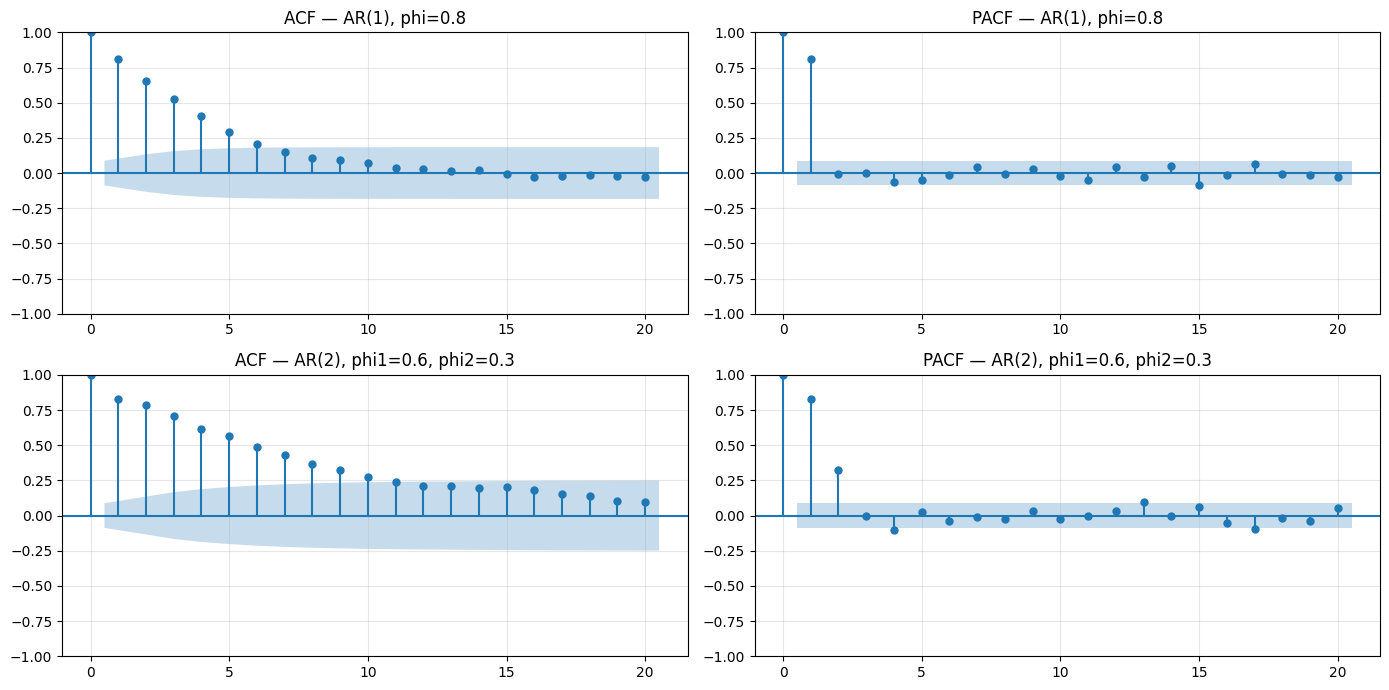

In [4]:
def simulate_ar2(phi1, phi2, n=500, sigma=1.0):
    x = np.zeros(n)
    for t in range(2, n):
        x[t] = phi1 * x[t-1] + phi2 * x[t-2] + np.random.normal(0, sigma)
    return x

ar1_series = simulate_ar1(phi=0.8, n=500)
ar2_series = simulate_ar2(phi1=0.6, phi2=0.3, n=500)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

plot_acf( ar1_series, lags=20, ax=axes[0, 0])
axes[0, 0].set_title('ACF — AR(1), phi=0.8')

plot_pacf(ar1_series, lags=20, ax=axes[0, 1], method='ywm')
axes[0, 1].set_title('PACF — AR(1), phi=0.8')

plot_acf( ar2_series, lags=20, ax=axes[1, 0])
axes[1, 0].set_title('ACF — AR(2), phi1=0.6, phi2=0.3')

plot_pacf(ar2_series, lags=20, ax=axes[1, 1], method='ywm')
axes[1, 1].set_title('PACF — AR(2), phi1=0.6, phi2=0.3')

plt.tight_layout()
plt.show()


### ✅ MODEL ANSWER — Written Response 3.1

> **1. AR(1) PACF:** Exactly 1 significant lag (lag 1). This correctly identifies the
> AR order as 1.
>
> **2. AR(2) PACF:** 2 significant lags (lags 1 and 2), dropping inside the CI band
> after that. This correctly identifies the AR order as 2.
>
> **3. Why not ACF?** The ACF includes both direct and indirect effects. For an AR process,
> lag-1 influences lag-2 through lag-1, so all lags appear correlated even in an AR(1).
> The ACF always decays gradually, making it hard to read the order. The PACF controls
> for intermediate lags, isolating the *direct* effect at each lag.
